phase flip noise model on 6 qubit cluster channel 

global phase: π
     ┌─────────┐┌────┐┌─────────┐           ░ ┌───────┐┌────┐┌────────┐┌────┐»
q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────────░─┤ Rz(π) ├┤ √X ├┤ Rz(2π) ├┤ √X ├»
     └─────────┘└────┘└─────────┘┌─┴─┐      ░ └───────┘└────┘└────────┘└────┘»
q_1: ────────────────────────────┤ X ├──■───░────────────────────────────────»
                                 └───┘┌─┴─┐ ░                                »
q_2: ─────────────────────────────────┤ X ├─░────────────────────────────────»
     ┌─────────┐┌────┐┌─────────┐     └───┘ ░                                »
q_3: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────────░────────────────────────────────»
     └─────────┘└────┘└─────────┘┌─┴─┐      ░                                »
q_4: ────────────────────────────┤ X ├──■───░────────────────────────────────»
                                 └───┘┌─┴─┐ ░ ┌───────┐┌────┐┌────────┐┌────┐»
q_5: ─────────────────────────────────┤ X ├─░─┤ Rz(π) ├┤ √X ├┤ Rz(2π) ├┤ √X ├»
                                    

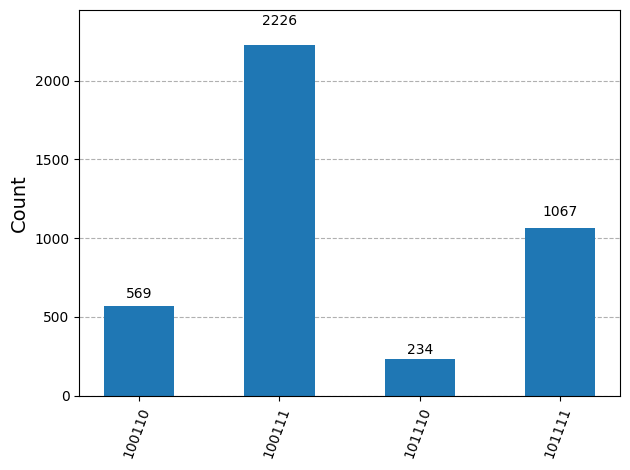

In [ ]:
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise import pauli_error

# ============================================================
# PARAMETERS
# ============================================================

shots = 4096

# Phase flip probability
p = 0.8

# Alice's 3-qubit message
message = "XIX"

# ============================================================
# CREATE CIRCUIT
# ============================================================

qc = QuantumCircuit(6,6)

# ============================================================
# CLUSTER STATE PREPARATION
# ============================================================

# --- Block 1: Prepare GHZ state on qubits 0, 1, 2 ---
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

# --- Block 2: Prepare GHZ state on qubits 3, 4, 5 ---
qc.h(3)
qc.cx(3, 4)
qc.cx(4, 5)

qc.barrier()

# ============================================================
# ALICE ENCODING
# Alice owns:
# ============================================================

alice = [0,3,5]

for op, qubit in zip(message, alice):

    if op == 'I':
        pass

    elif op == 'X':
        qc.x(qubit)

    elif op == 'Y':
        qc.y(qubit)

    elif op == 'Z':
        qc.z(qubit)

qc.barrier()

# ============================================================
# NOISE CHANNEL
# Identity gates are inserted only so the noise model acts only during transmission of qubits from alice to bob.
# ============================================================

qc.id(0)
qc.id(3)
qc.id(5)

qc.barrier()

# ============================================================
# BOB DECODER
# Decoder has been constructed from the orthogonal basis.
# ============================================================


qc.cx(3,5)
qc.cx(3,4)
qc.cx(0,2)
qc.cx(0,1)
qc.barrier()

qc.h(0)
qc.h(3)
qc.barrier()

qc.measure([0,1,2,3,4,5],[0,1,2,3,4,5])

# ============================================================
# PHASE FLIP NOISE MODEL
# ============================================================

from qiskit_aer.noise import pauli_error, NoiseModel

# Phase-flip error
phase_flip = pauli_error([
    ('Z', p),
    ('I', 1-p)
])

noise_model = NoiseModel()

# Apply phase-flip to all single-qubit gates
for gate in ['id']:
    noise_model.add_all_qubit_quantum_error(
        phase_flip,
        [gate]
    )

backend = AerSimulator(noise_model=noise_model)

tqc = transpile(qc, backend, optimization_level=0)
print(tqc)

result = backend.run(
    tqc,
    shots=shots
).result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)

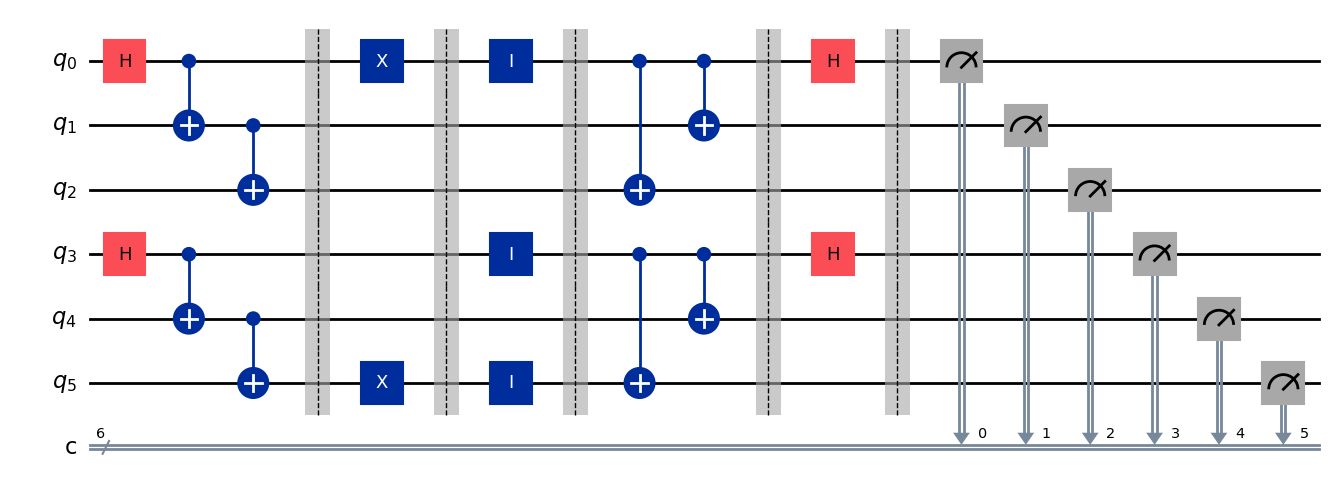

In [5]:
qc.draw(output="mpl")

plotting phase flip graph 

<>:51: SyntaxWarning: invalid escape sequence '\e'
<>:51: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ranga\AppData\Local\Temp\ipykernel_12764\3305529679.py:51: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Noise parameter (0 ≤ $\eta_F$ ≤ 1)', fontsize=12)


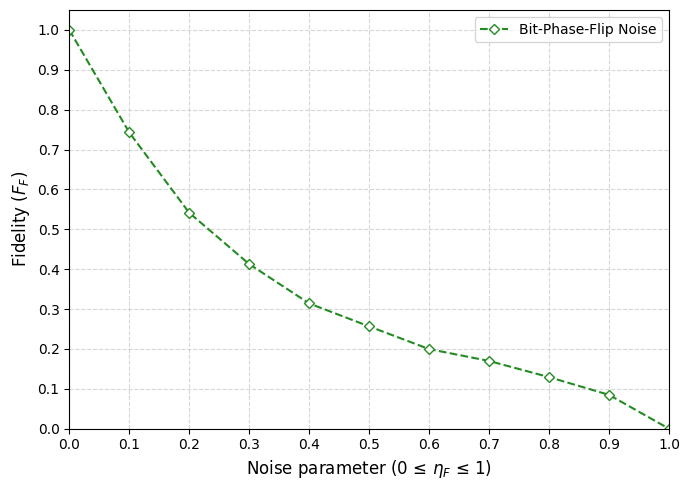

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Data
# ================================

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4,
              0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

y = np.array([1.0,
              0.742919,
              0.5415039,
              0.41284,
              0.3142,
              0.25659,
              0.199707,
              0.169921,
              0.12939,
              0.08496,
              0.0])


plt.figure(figsize=(7,5))

plt.plot(
    x,
    y,
    color='forestgreen',
    linestyle='--',
    marker='D',
    markersize=5,
    markerfacecolor='white',
    linewidth=1.5,
    label='Phase-Flip Noise'
)


plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xticks(np.arange(0,1.1,0.1))
plt.yticks(np.arange(0,1.1,0.1))

plt.xlabel('Noise parameter (0 ≤ $\eta_W$ ≤ 1)', fontsize=12)
plt.ylabel('Fidelity ($F_W$)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()